In [6]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [7]:
# Load processed data
df_urdu = pd.read_csv('../data/processed/urdu_news_features.csv')

# Load TF-IDF vectorizer
with open('../models/tfidf_urdu.pkl', 'rb') as f:
    tfidf_urdu = pickle.load(f)

# Transform text to features
X = tfidf_urdu.transform(df_urdu['text'])
y = df_urdu['label']

print("Data loaded.")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

Data loaded.
X shape: (10440, 5000)
y distribution:
label
real    6339
fake    4101
Name: count, dtype: int64


In [8]:
# Train test split - 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # ensures same label distribution in train and test
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set: 8352 rows
Test set: 2088 rows

Training label distribution:
label
real    5071
fake    3281
Name: count, dtype: int64

Test label distribution:
label
real    1268
fake     820
Name: count, dtype: int64


In [10]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=1000
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced', 
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42
    ),
    'Naive Bayes': MultinomialNB()
}

# Train and evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, pos_label='fake', average='binary')
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'f1_fake': round(f1, 4)
    }
    print(f"{name} - F1 (fake class): {f1:.4f}")

Logistic Regression - F1 (fake class): 0.9068
Linear SVM - F1 (fake class): 0.9217
Random Forest - F1 (fake class): 0.9114
Naive Bayes - F1 (fake class): 0.8444


In [9]:
# Fix trailing whitespace in labels
df_urdu['label'] = df_urdu['label'].str.strip()

# Rebuild X and y
X = tfidf_urdu.transform(df_urdu['text'])
y = df_urdu['label']

# Verify
print(y.unique())

# Redo train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Labels fixed. Ready to train.")

['fake' 'real']
Labels fixed. Ready to train.


In [11]:
# Detailed classification reports
for name, result in results.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, result['predictions']))


Logistic Regression
              precision    recall  f1-score   support

        fake       0.88      0.93      0.91       820
        real       0.95      0.92      0.94      1268

    accuracy                           0.92      2088
   macro avg       0.92      0.93      0.92      2088
weighted avg       0.93      0.92      0.93      2088


Linear SVM
              precision    recall  f1-score   support

        fake       0.91      0.93      0.92       820
        real       0.96      0.94      0.95      1268

    accuracy                           0.94      2088
   macro avg       0.93      0.94      0.94      2088
weighted avg       0.94      0.94      0.94      2088


Random Forest
              precision    recall  f1-score   support

        fake       0.91      0.92      0.91       820
        real       0.95      0.94      0.94      1268

    accuracy                           0.93      2088
   macro avg       0.93      0.93      0.93      2088
weighted avg       0.93   

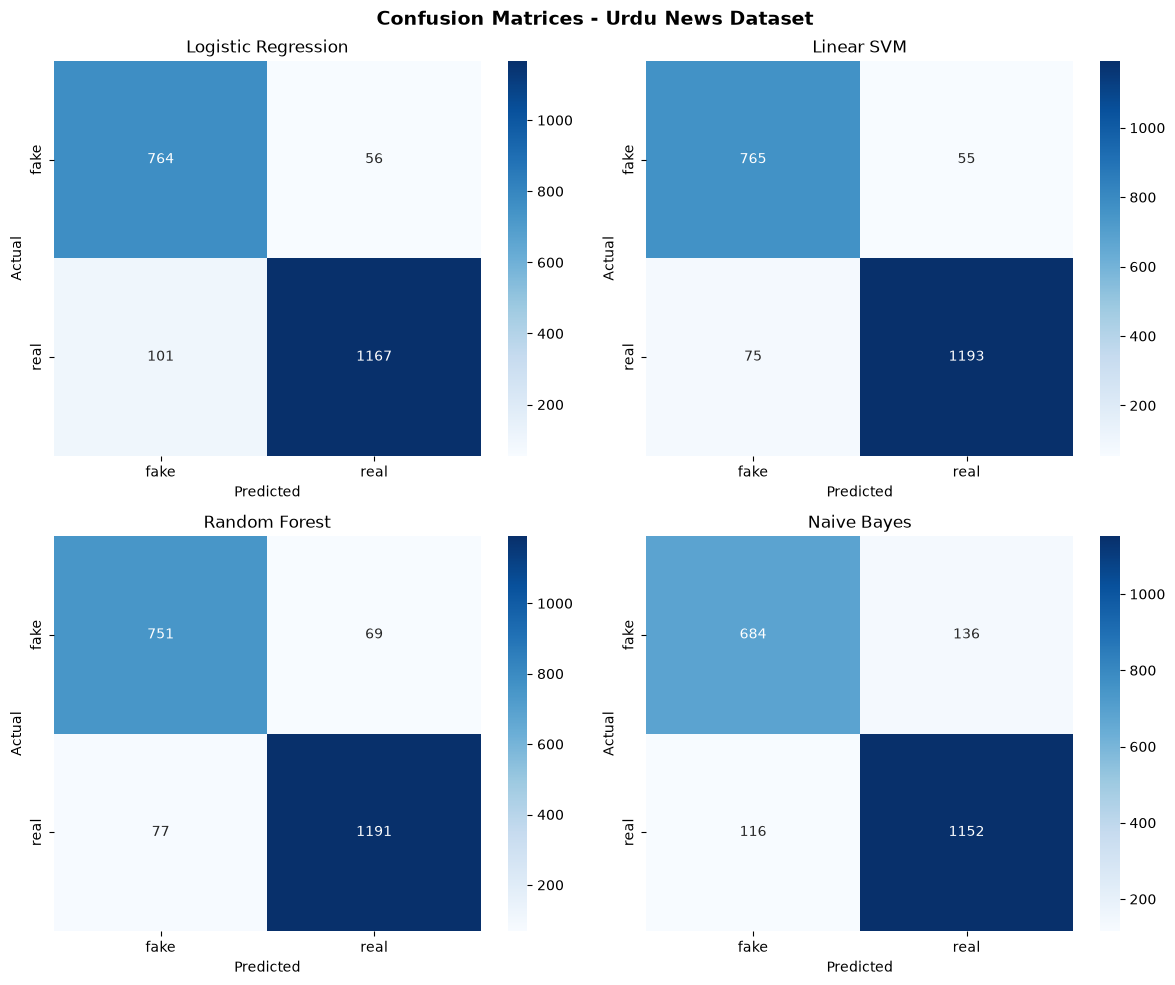

Saved.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'], labels=['fake', 'real'])
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=['fake', 'real'],
        yticklabels=['fake', 'real'],
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - Urdu News Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/confusion_matrices_urdu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

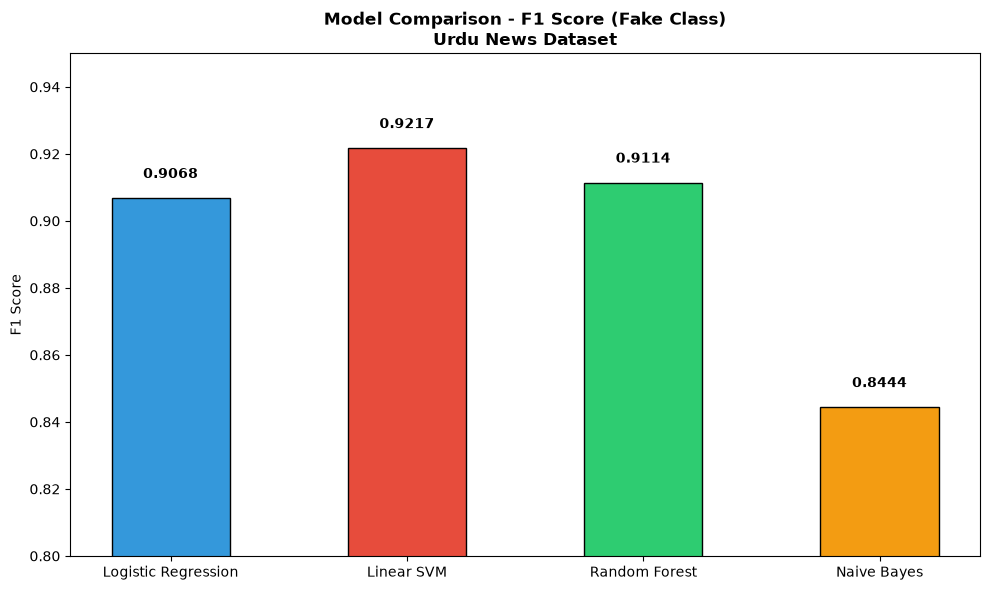

Saved.


In [13]:
# Model comparison bar chart
model_names = list(results.keys())
f1_scores = [results[name]['f1_fake'] for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, f1_scores, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], 
               edgecolor='black', width=0.5)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Model Comparison - F1 Score (Fake Class)\nUrdu News Dataset', fontweight='bold')
plt.ylabel('F1 Score')
plt.ylim(0.80, 0.95)
plt.tight_layout()
plt.savefig('../results/figures/model_comparison_urdu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [14]:
# Save best model - Linear SVM
best_model = results['Linear SVM']['model']

with open('../models/best_model_urdu.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved: Linear SVM")
print(f"F1 Score (fake class): {results['Linear SVM']['f1_fake']}")
print(f"\nModel saved to: ../models/best_model_urdu.pkl")

# Summary table
summary = pd.DataFrame({
    'Model': model_names,
    'F1 (fake)': f1_scores,
    'Accuracy': [
        round((results[name]['predictions'] == y_test).mean(), 4) 
        for name in model_names
    ]
})
summary = summary.sort_values('F1 (fake)', ascending=False).reset_index(drop=True)
print("\nFinal Model Summary:")
print(summary)

Best model saved: Linear SVM
F1 Score (fake class): 0.9217

Model saved to: ../models/best_model_urdu.pkl

Final Model Summary:
                 Model  F1 (fake)  Accuracy
0           Linear SVM     0.9217    0.9377
1        Random Forest     0.9114    0.9301
2  Logistic Regression     0.9068    0.9248
3          Naive Bayes     0.8444    0.8793
